# Policy Testing — Result Analysis

Paper-style visualisation of the OFAT sensitivity sweeps produced by
`testing/evaluate_policy.py`. This notebook reads **only the CSV files** under
`testing_results/csv/` (no model, no environment), writes every figure used in
Section 7 of the report to `testing_results/plots/`, and mirrors them into
`report/figures/` in the last cell. Regenerating the whole of Section 7 is a
single run of this notebook.

**Inputs**  `agg_<axis>.csv`, `detail_<axis>.csv`, `agg_epoch.csv`,
`agg_fault.csv`, `heatmap_<pair>.csv`, plus the auto-nav rerun under
`testing_results/auto_nav/csv/`.
**Outputs** `fig_{n_agents,vision,comm,density,max_steps}.png`, `fig_epoch.png`,
`fig_fault.png`, `fig_nbroken.png`, `fig_heatmap_<pair>.png`.

Two conventions are set in the next cell and documented there: `YLIM_MODE`
(how far the y-axes are zoomed, with `coverage` deliberately exempted) and
`TTF_UNITS` (time-to-find in rounds rather than agent-turns).

In [1]:
import os, glob, math, shutil
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Locate the repo root so the notebook works whether it is launched from the
# project root or from inside testing/ (nbconvert sets cwd to the notebook dir).
def _find_root(start):
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.exists(os.path.join(d, "configs", "default.yaml")):
            return d
        d = os.path.dirname(d)
    return os.path.abspath(start)

ROOT     = _find_root(os.getcwd())
CSV_DIR  = os.path.join(ROOT, "testing_results", "csv")
AUTO_DIR = os.path.join(ROOT, "testing_results", "auto_nav", "csv")
PLOT_DIR = os.path.join(ROOT, "testing_results", "plots")
FIG_DIR  = os.path.join(ROOT, "report", "figures")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(CSV_DIR,  exist_ok=True)

def rel(path):
    """Repo-relative path, so saved outputs read the same on every machine."""
    return os.path.relpath(path, ROOT).replace(os.sep, "/")


# ---------------------------------------------------------------------------
# y-axis policy
# ---------------------------------------------------------------------------
# Bounded metrics (success, coverage, SPL) have a natural full range, but
# pinning every panel to it flattens real effects: the communication sweep
# spans 87.2-89.0 % success and reads as a straight line on a 0-100 % axis.
#
#   "zoom"   y-limits fitted to the data *and* its CI / std band, +/- a 12 %
#            margin.  Trends become readable; the absolute level has to be
#            read off the axis.
#   "fixed"  every bounded panel pinned to its full range.
#
# Unbounded panels (return, time-to-find, collisions) always autoscale.
YLIM_MODE = "zoom"

# Panels exempted from the zoom, whatever YLIM_MODE says.  `coverage` is the
# one bounded metric whose variation along the flat axes is dominated by
# sampling noise -- the whole communication sweep lies between 53.0 % and
# 54.3 %, about one point over 500 seeds, and it carries no confidence band to
# warn the reader.  Zooming it would turn that noise into an apparent trend, so
# it stays on the full 0-100 % range where it correctly reads as flat.
ALWAYS_FIXED = {"coverage"}

# ---------------------------------------------------------------------------
# Time-to-find units
# ---------------------------------------------------------------------------
# `ttf` in the CSVs is `info["step"]` at success, which counts *agent-turns*:
# the episode budget is `max_steps * n_agents` and every drone consumes one
# turn per round -- wrecks included, via `GridEnv._noop_turn`.  Raw ttf is
# therefore ~N x the mission length and not comparable to the step budget T
# quoted elsewhere in the report.
#
#   "rounds"       ttf / N  =  rounds to success, the same unit as T.  Shows
#                              the real, sublinear speed-up from a larger team
#                              instead of a mechanical increase with N.
#   "agent_steps"  raw ttf     (the convention of the first draft)
TTF_UNITS = "rounds"
REF_N     = 3          # team size at the reference operating point

# ---- publication style ----------------------------------------------------
mpl.rcParams.update({
    "figure.dpi":        120,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    "mathtext.fontset":  "stix",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9.5,
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.linewidth":    0.5,
    "grid.alpha":        0.35,
    "lines.linewidth":   1.7,
    "lines.markersize":  5,
    "legend.fontsize":   8,
    "legend.frameon":    True,
    "legend.framealpha": 0.92,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
})

C_ID  = "#1f4e79"   # in-distribution
C_OOD = "#c0392b"   # out-of-distribution
C_2   = "#2e8b57"   # secondary series

AXIS_LABEL = {
    "n_agents":  r"number of drones $N$",
    "vision":    r"vision radius $v$",
    "comm":      r"communication range $c$",
    "density":   r"obstacle density $\rho$",
    "max_steps": r"step budget $T$",
    "fault":     r"fault probability $p_\mathrm{fault}$",
    "epoch":     "training episode",
}

# ---------------------------------------------------------------------------
# In-distribution ranges
# ---------------------------------------------------------------------------
# `in_dist` as written by evaluate_policy.py used to mislabel two axes: rho = 0
# sits BELOW the trained floor of 0.10, and the step budget was never a
# randomization factor at all (training fixed T = 200). The harness has since
# been corrected, but the CSVs in testing_results/ predate the fix, so the flag
# is recomputed here from the training ranges themselves, which are the single
# source of truth (configs/default.yaml: domain_randomization, plus the
# curriculum's max_steps). Axes absent from this dict keep the CSV's own flag.
TRAINED_RANGE = {
    "density":   (0.10, 0.30),   # domain_randomization.obstacle_density
    "max_steps": (200, 200),     # never randomized: the curriculum pins T = 200
}

def _fix_in_dist(axis, df):
    """Recompute `in_dist` from TRAINED_RANGE (see the note above)."""
    rng = TRAINED_RANGE.get(axis)
    if rng is not None and "value" in df.columns:
        lo, hi = rng
        df = df.copy()
        df["in_dist"] = ((df.value >= lo) & (df.value <= hi)).astype(int)
    return df

def load_agg(axis, root=None):
    p = os.path.join(root or CSV_DIR, f"agg_{axis}.csv")
    if not os.path.exists(p):
        return None
    df = pd.read_csv(p).sort_values("value").reset_index(drop=True)
    return _fix_in_dist(axis, df)

def team_size(axis, df):
    """Team size at each swept point (N varies only on the n_agents axis)."""
    p = os.path.join(CSV_DIR, f"detail_{axis}.csv")
    if os.path.exists(p):
        n = df.value.map(pd.read_csv(p).groupby("value").n_agents.first())
        if n.notna().all():
            return n.astype(float)
    return pd.Series(float(REF_N), index=df.index)

def ttf_series(axis, df):
    """Time-to-find in the configured unit, with its axis label."""
    if TTF_UNITS == "rounds":
        return df.ttf / team_size(axis, df), "rounds to success"
    return df.ttf, "agent-turns to success"

# ---- y-limit policy -------------------------------------------------------
def panel_mode(key):
    """Per-panel y-axis mode: `ALWAYS_FIXED` panels ignore YLIM_MODE."""
    return "fixed" if key in ALWAYS_FIXED else YLIM_MODE

def autolim(ax, *series, pad=0.12, lo_clip=None, hi_clip=None):
    """Fit the y-axis to the data (and any band) with a proportional margin."""
    vals = [np.asarray(s, dtype=float).ravel() for s in series if s is not None]
    v = np.concatenate(vals) if vals else np.array([])
    v = v[np.isfinite(v)]
    if v.size == 0:
        return
    lo, hi = float(v.min()), float(v.max())
    span = (hi - lo) or max(abs(hi), 1.0) * 0.1
    lo, hi = lo - pad * span, hi + pad * span
    if lo_clip is not None: lo = max(lo, lo_clip)
    if hi_clip is not None: hi = min(hi, hi_clip)
    ax.set_ylim(lo, hi)

def set_ylim(ax, key, fixed, y, band=None, clip=(None, None)):
    """Pin the panel to `fixed`, or fit it to the data, per `panel_mode(key)`."""
    if panel_mode(key) == "fixed" and fixed is not None:
        ax.set_ylim(*fixed)
    else:
        autolim(ax, y, *(list(band) if band is not None else []),
                lo_clip=clip[0], hi_clip=clip[1])

print("CSV files found:", sorted(os.path.basename(p) for p in glob.glob(os.path.join(CSV_DIR, '*.csv'))))
print(f"YLIM_MODE={YLIM_MODE!r}  always fixed: {sorted(ALWAYS_FIXED)}  TTF_UNITS={TTF_UNITS!r}")

CSV files found: ['agg_comm.csv', 'agg_density.csv', 'agg_epoch.csv', 'agg_fault.csv', 'agg_max_steps.csv', 'agg_n_agents.csv', 'agg_vision.csv', 'detail_comm.csv', 'detail_density.csv', 'detail_epoch.csv', 'detail_fault.csv', 'detail_max_steps.csv', 'detail_n_agents.csv', 'detail_vision.csv', 'heatmap_nagents_comm.csv', 'heatmap_vision_density.csv', 'summary_table.csv']
YLIM_MODE='zoom'  always fixed: ['coverage']  TTF_UNITS='rounds'


## 1 — Per-axis sensitivity figures

One figure per swept factor. Filled circles = in-distribution (values seen during
training); open red squares = **out-of-distribution** extrapolation. The grey band
and dashed lines delimit the training range.

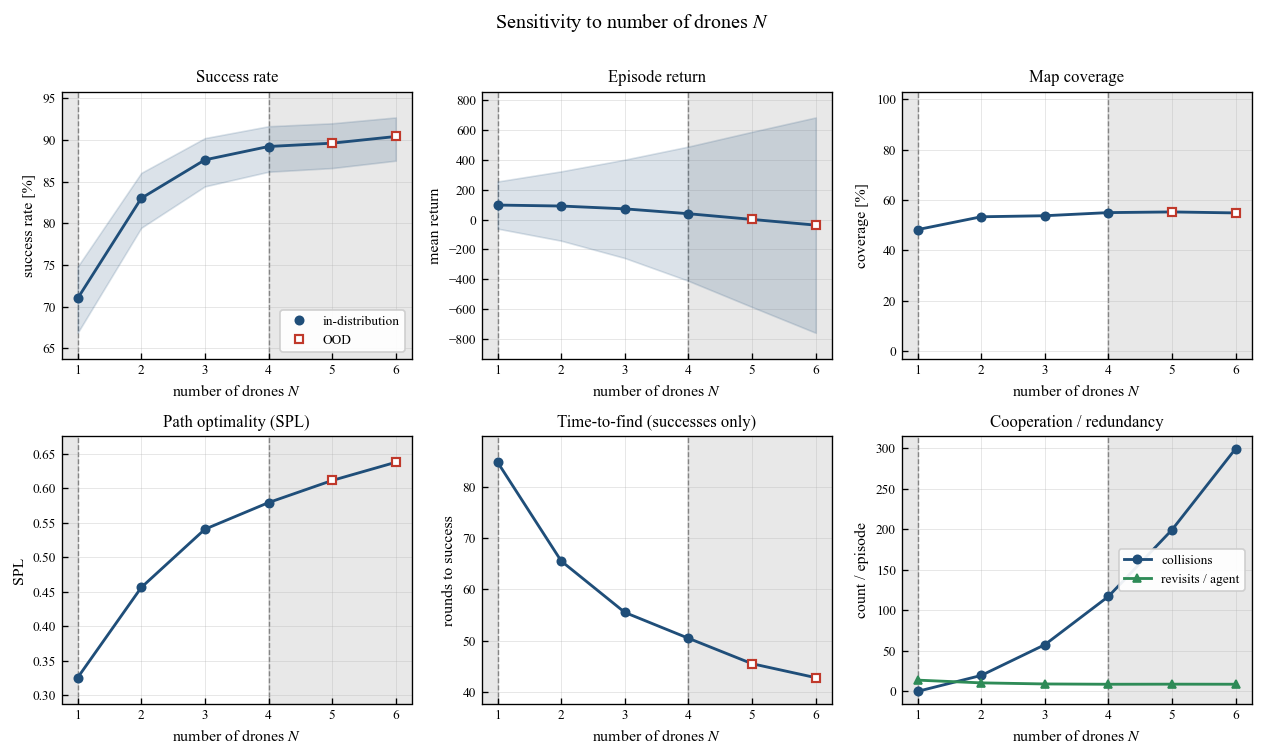

  saved testing_results/plots/fig_n_agents.png


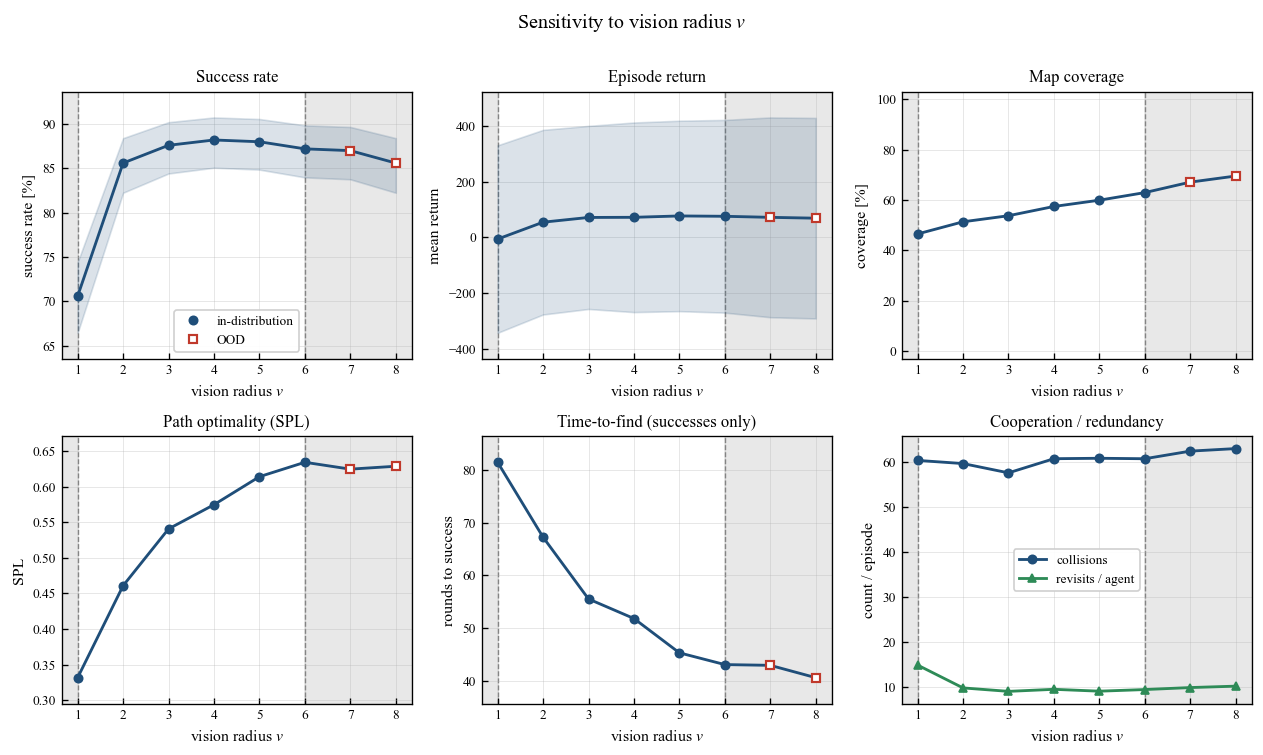

  saved testing_results/plots/fig_vision.png


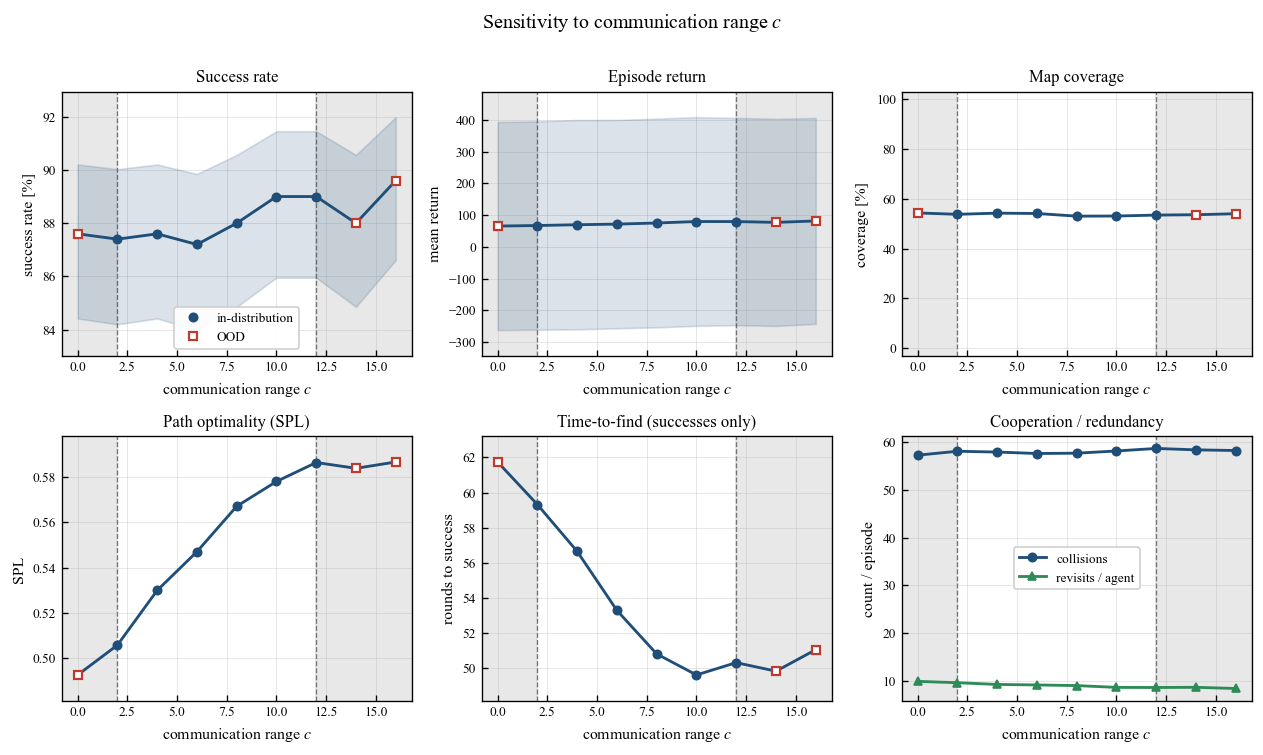

  saved testing_results/plots/fig_comm.png


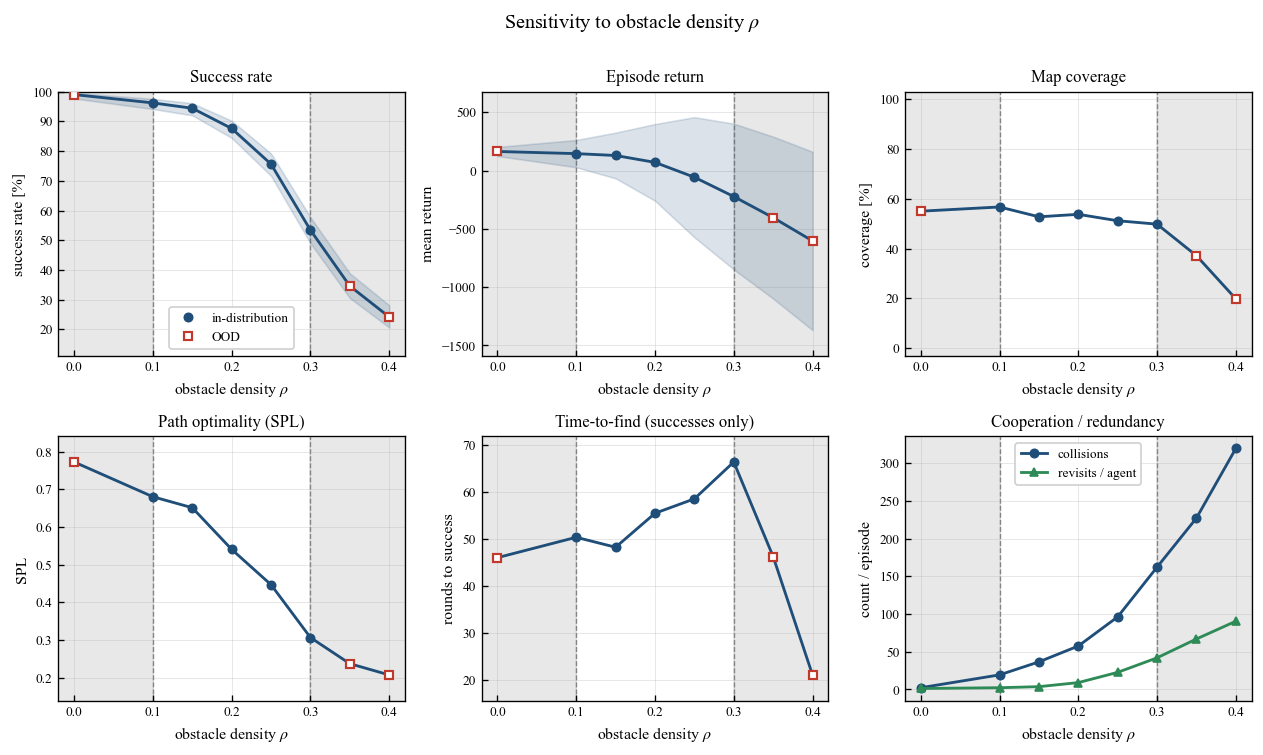

  saved testing_results/plots/fig_density.png


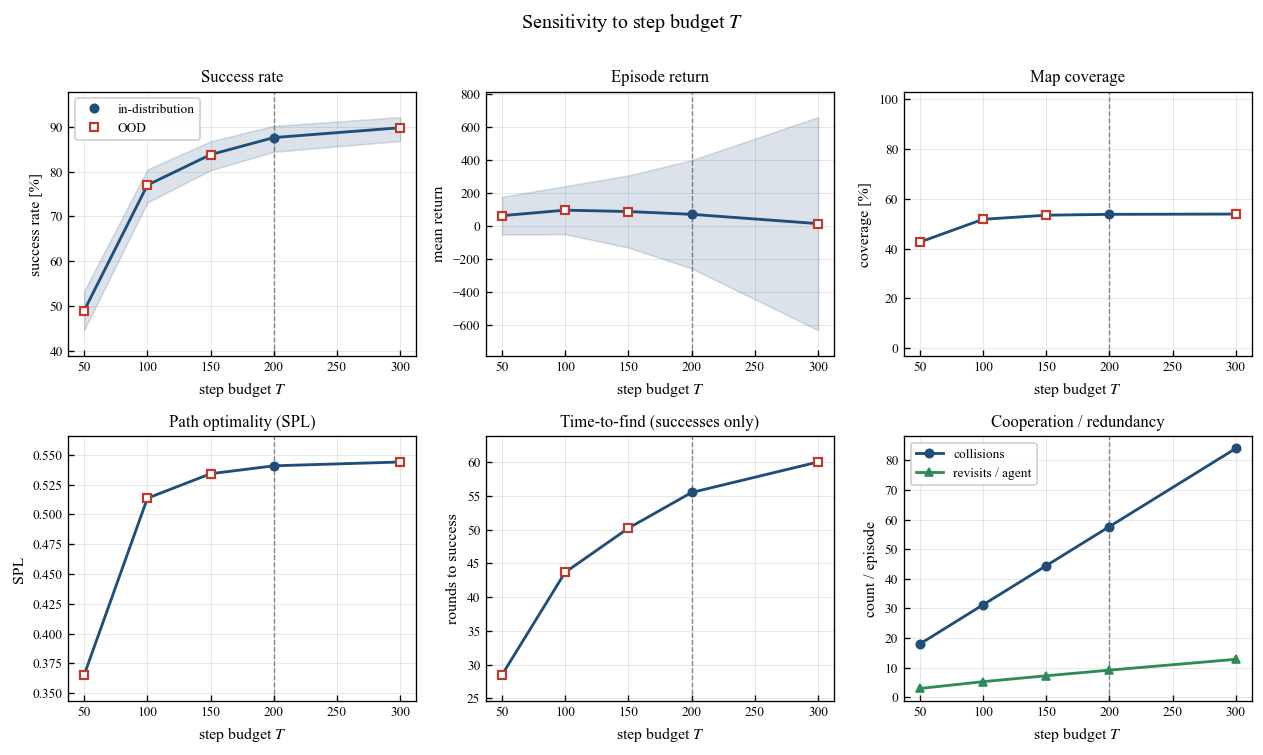

  saved testing_results/plots/fig_max_steps.png


In [2]:
def _shade_ood(ax, df):
    idv = df.loc[df.in_dist == 1, "value"]
    if idv.empty:
        return
    lo, hi = idv.min(), idv.max()
    x0, x1 = ax.get_xlim()
    if lo == hi:
        # Degenerate training "range": the factor was never randomized (the
        # step budget, fixed at T = 200). Shading both sides would grey out the
        # whole panel and say nothing, so mark the trained value only.
        ax.axvline(lo, ls="--", lw=0.8, color="0.45", zorder=1)
        return
    if lo > x0: ax.axvspan(x0, lo, color="0.85", alpha=0.6, zorder=0)
    if hi < x1: ax.axvspan(hi, x1, color="0.85", alpha=0.6, zorder=0)
    ax.axvline(lo, ls="--", lw=0.8, color="0.45", zorder=1)
    ax.axvline(hi, ls="--", lw=0.8, color="0.45", zorder=1)
    ax.set_xlim(x0, x1)

def _metric(ax, df, y, ylabel, title, key, band=None, shade=True,
            fixed=None, clip=(None, None), legend=False):
    y   = np.asarray(y, dtype=float)
    idm = (df.in_dist == 1).values
    ax.plot(df.value, y, "-", color=C_ID, zorder=3)
    if band is not None:
        ax.fill_between(df.value, band[0], band[1], color=C_ID, alpha=0.16, zorder=2)
    ax.plot(df.value[idm],  y[idm],  "o", color=C_ID, zorder=4, label="in-distribution")
    if (~idm).any():
        ax.plot(df.value[~idm], y[~idm], "s", mfc="white", mec=C_OOD,
                color=C_OOD, mew=1.3, zorder=4, label="OOD")
    ax.set_ylabel(ylabel); ax.set_title(title)
    if shade: _shade_ood(ax, df)
    set_ylim(ax, key, fixed, y, band, clip)
    if legend: ax.legend(loc="best")

def plot_axis(axis):
    df = load_agg(axis)
    if df is None:
        print("  (skip, no CSV):", axis); return
    xl = AXIS_LABEL.get(axis, axis)
    fig, axs = plt.subplots(2, 3, figsize=(10.6, 6.2))

    _metric(axs[0,0], df, df.success_rate*100, "success rate [%]", "Success rate",
            "success", band=(df.wilson_lo*100, df.wilson_hi*100),
            fixed=(-3, 103), clip=(0, 100), legend=True)

    _metric(axs[0,1], df, df.mean_reward, "mean return", "Episode return", "reward",
            band=(df.mean_reward - df.std_reward, df.mean_reward + df.std_reward))

    _metric(axs[0,2], df, df.coverage*100, "coverage [%]", "Map coverage",
            "coverage", fixed=(-3, 103), clip=(0, 100))

    _metric(axs[1,0], df, df.spl, "SPL", "Path optimality (SPL)", "spl",
            fixed=(-0.02, 1.02), clip=(0, 1))

    ttf, ttf_lab = ttf_series(axis, df)
    m = (df.ttf_n > 0).values
    _metric(axs[1,1], df[m].reset_index(drop=True), np.asarray(ttf, dtype=float)[m],
            ttf_lab, "Time-to-find (successes only)", "ttf", clip=(0, None))

    ax = axs[1,2]
    ax.plot(df.value, df.collisions, "-o", color=C_ID, label="collisions")
    ax.plot(df.value, df.revisits,  "-^", color=C_2,  label="revisits / agent")
    ax.set_ylabel("count / episode"); ax.set_title("Cooperation / redundancy")
    ax.legend(loc="best"); _shade_ood(ax, df)

    for ax in axs.ravel():
        ax.set_xlabel(xl)
    fig.suptitle(f"Sensitivity to {xl}", fontsize=12, y=1.005)
    fig.tight_layout()
    out = os.path.join(PLOT_DIR, f"fig_{axis}.png")
    fig.savefig(out); plt.show(); print("  saved", rel(out))

for axis in ["n_agents", "vision", "comm", "density", "max_steps"]:
    plot_axis(axis)

### Team-size speed-up

The numbers behind the *time-to-find* panel of `fig_n_agents.png`, quoted in
Section 7.3 of the report. Dividing `ttf` by `N` converts agent-turns into
rounds, i.e. mission time in the step budget's own unit; the speed-up is real
but strongly sublinear, which is what the rising collision count and the
overlap between swept regions predict.

In [3]:
def speedup_table():
    df = load_agg("n_agents")
    if df is None:
        print("  (skip) no agg_n_agents.csv"); return None
    rounds = df.ttf / team_size("n_agents", df)
    speed  = rounds.iloc[0] / rounds
    return pd.DataFrame({
        "N":                     df.value,
        "in_dist":               df.in_dist,
        "ttf_agent_turns":       df.ttf.round(1),
        "ttf_rounds":            rounds.round(1),
        "speedup":               speed.round(2),
        "parallel_efficiency_%": (100*speed/df.value).round(1),
    })

_tbl = speedup_table()
print(_tbl.to_string(index=False) if _tbl is not None else "")

 N  in_dist  ttf_agent_turns  ttf_rounds  speedup  parallel_efficiency_%
 1        1             84.9        84.9     1.00                  100.0
 2        1            131.1        65.5     1.29                   64.7
 3        1            166.5        55.5     1.53                   51.0
 4        1            201.7        50.4     1.68                   42.1
 5        0            227.3        45.5     1.87                   37.3
 6        0            256.4        42.7     1.99                   33.1


## 2 — Learning curve over training

The reference operating point evaluated at every checkpoint
(`agg_epoch.csv`). Shows how success, return, coverage and path optimality
evolve with training episodes on the held-out test maps.

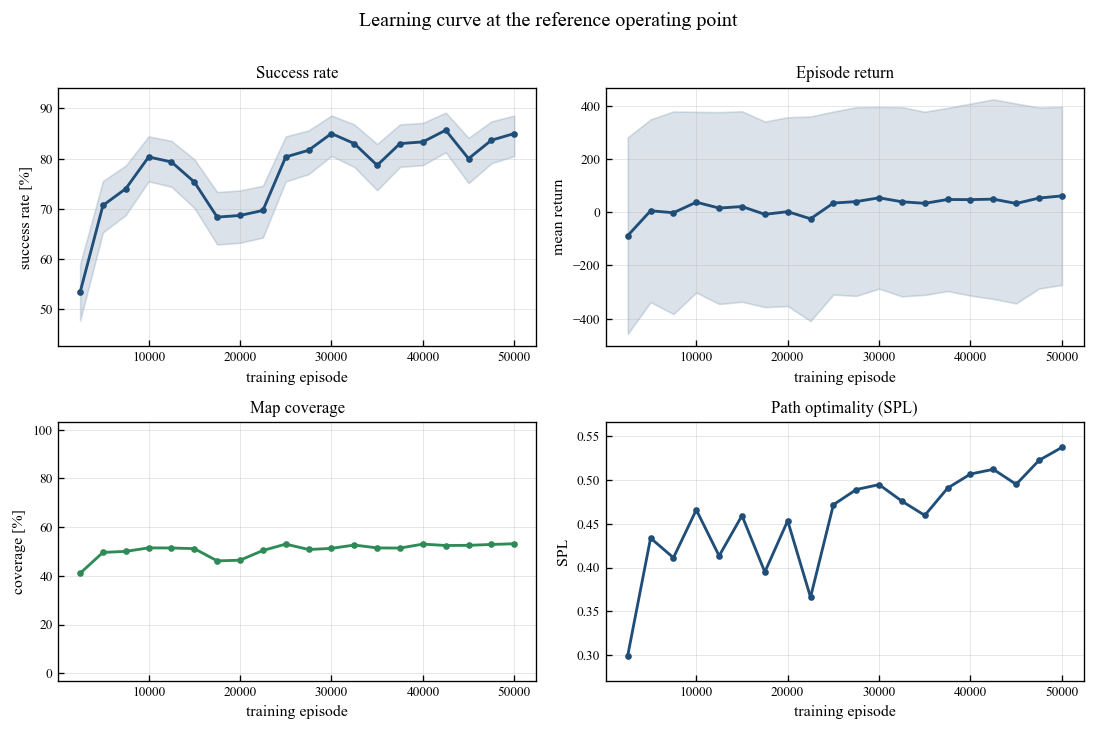

  saved testing_results/plots/fig_epoch.png


In [4]:
def plot_epoch():
    df = load_agg("epoch")
    if df is None:
        print("  (skip) no agg_epoch.csv"); return
    fig, axs = plt.subplots(2, 2, figsize=(9.2, 6.0))
    x = df.value

    ax   = axs[0,0]
    band = (df.wilson_lo*100, df.wilson_hi*100)
    ax.fill_between(x, band[0], band[1], color=C_ID, alpha=0.16)
    ax.plot(x, df.success_rate*100, "-o", color=C_ID, ms=3)
    ax.set_ylabel("success rate [%]"); ax.set_title("Success rate")
    set_ylim(ax, "success", (-3, 103), df.success_rate*100, band, clip=(0, 100))

    ax   = axs[0,1]
    band = (df.mean_reward - df.std_reward, df.mean_reward + df.std_reward)
    ax.fill_between(x, band[0], band[1], color=C_ID, alpha=0.16)
    ax.plot(x, df.mean_reward, "-o", color=C_ID, ms=3)
    ax.set_ylabel("mean return"); ax.set_title("Episode return")

    ax = axs[1,0]
    ax.plot(x, df.coverage*100, "-o", color=C_2, ms=3)
    ax.set_ylabel("coverage [%]"); ax.set_title("Map coverage")
    set_ylim(ax, "coverage", (-3, 103), df.coverage*100, clip=(0, 100))

    ax = axs[1,1]
    ax.plot(x, df.spl, "-o", color=C_ID, ms=3)
    ax.set_ylabel("SPL"); ax.set_title("Path optimality (SPL)")
    set_ylim(ax, "spl", (-0.02, 1.02), df.spl, clip=(0, 1))

    for ax in axs.ravel():
        ax.set_xlabel("training episode")
    fig.suptitle("Learning curve at the reference operating point", fontsize=12, y=1.005)
    fig.tight_layout()
    out = os.path.join(PLOT_DIR, "fig_epoch.png")
    fig.savefig(out); plt.show(); print("  saved", rel(out))

plot_epoch()

## 3 — Fault robustness

The learned policy (`testing_results/csv/agg_fault.csv`) against the BFS
auto-nav hybrid (`testing_results/auto_nav/csv/agg_fault.csv`), then the
composition of episodes by number of drones lost and success conditioned on
survivors (`detail_fault.csv`).

`fig_nbroken.png` keeps full 0–100 % axes on both panels: they are bar charts,
and truncating a bar axis misstates the very ratios the bars encode.

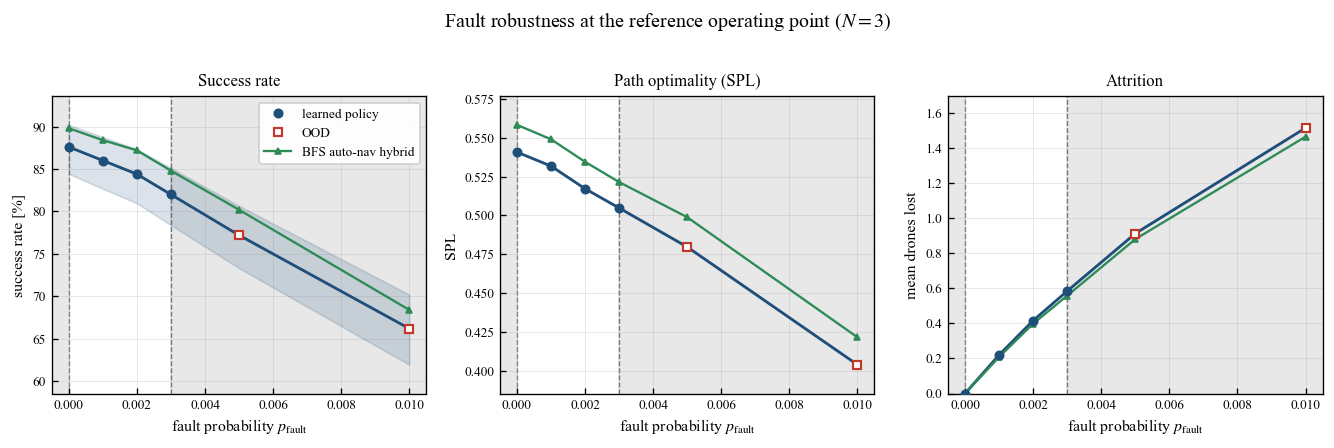

  saved testing_results/plots/fig_fault.png


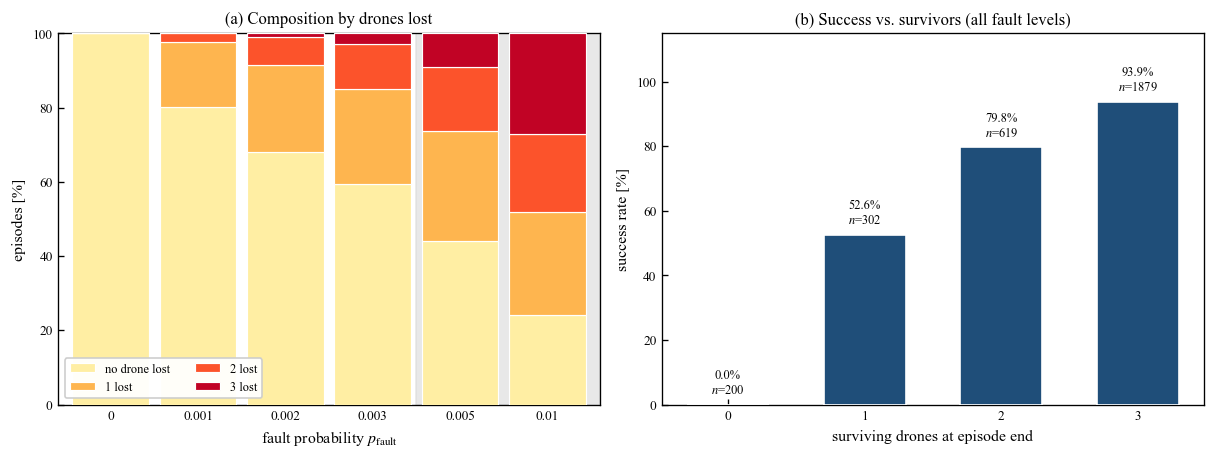

  saved testing_results/plots/fig_nbroken.png
          mean  size  success_pct
surv                             
0     0.000000   200          0.0
1     0.526490   302         52.6
2     0.798061   619         79.8
3     0.938797  1879         93.9


In [5]:
def plot_fault():
    df = load_agg("fault")
    an = load_agg("fault", root=AUTO_DIR)
    if df is None:
        print("  (skip) no agg_fault.csv"); return
    idm = (df.in_dist == 1).values
    xl  = AXIS_LABEL["fault"]

    fig, axs = plt.subplots(1, 3, figsize=(11.2, 3.6))

    def _panel(ax, col, scale, ylabel, title, key, band=None,
               fixed=None, clip=(None, None)):
        y = np.asarray(df[col] * scale, dtype=float)
        b = (df[band[0]]*scale, df[band[1]]*scale) if band else None
        if b is not None:
            ax.fill_between(df.value, b[0], b[1], color=C_ID, alpha=0.16, zorder=2)
        ax.plot(df.value, y, "-", color=C_ID, zorder=3)
        ax.plot(df.value[idm], y[idm], "o", color=C_ID, zorder=4, label="learned policy")
        if (~idm).any():
            ax.plot(df.value[~idm], y[~idm], "s", mfc="white", mec=C_OOD,
                    color=C_OOD, mew=1.3, zorder=4, label="OOD")
        ya = None
        if an is not None:
            ya = np.asarray(an[col] * scale, dtype=float)
            ax.plot(an.value, ya, "-^", color=C_2, lw=1.4, ms=4, zorder=3,
                    label="BFS auto-nav hybrid")
        ax.set_xlabel(xl); ax.set_ylabel(ylabel); ax.set_title(title)
        _shade_ood(ax, df)
        if panel_mode(key) == "fixed" and fixed is not None:
            ax.set_ylim(*fixed)
        else:
            extra = [b[0], b[1]] if b is not None else []
            autolim(ax, y, ya, *extra, lo_clip=clip[0], hi_clip=clip[1])

    _panel(axs[0], "success_rate", 100, "success rate [%]", "Success rate",
           "success", band=("wilson_lo", "wilson_hi"), fixed=(-3, 103), clip=(0, 100))
    axs[0].legend(loc="best")
    _panel(axs[1], "spl", 1, "SPL", "Path optimality (SPL)", "spl",
           fixed=(-0.02, 1.02), clip=(0, 1))
    _panel(axs[2], "n_broken", 1, "mean drones lost", "Attrition",
           "n_broken", clip=(0, None))

    fig.suptitle(r"Fault robustness at the reference operating point ($N = 3$)",
                 fontsize=12, y=1.02)
    fig.tight_layout()
    out = os.path.join(PLOT_DIR, "fig_fault.png")
    fig.savefig(out); plt.show(); print("  saved", rel(out))


def plot_nbroken():
    """Open up the fault aggregate: composition, and success vs. survivors."""
    p = os.path.join(CSV_DIR, "detail_fault.csv")
    if not os.path.exists(p):
        print("  (skip) no detail_fault.csv"); return
    d = pd.read_csv(p)
    d["surv"] = d.n_agents - d.n_broken
    levels = sorted(d.value.unique())
    kmax   = int(d.n_broken.max())

    fig, axs = plt.subplots(1, 2, figsize=(10.2, 3.9))

    # (a) composition of episodes by number of drones lost -------------------
    ax   = axs[0]
    xs   = np.arange(len(levels))
    bot  = np.zeros(len(levels))
    cmap = plt.get_cmap("YlOrRd")
    for k in range(kmax + 1):
        share = np.array([(d[d.value == v].n_broken == k).mean()*100 for v in levels])
        ax.bar(xs, share, bottom=bot, width=0.88, zorder=3,
               color=cmap(0.12 + 0.74*k/max(kmax, 1)), edgecolor="white", lw=0.7,
               label="no drone lost" if k == 0 else f"{k} lost")
        bot += share
    ind = [i for i, v in enumerate(levels) if d[d.value == v].in_dist.iloc[0] == 1]
    ax.set_xlim(-0.6, len(levels) - 0.4)
    if ind and max(ind) + 1 < len(levels):
        ax.axvspan(max(ind) + 0.5, len(levels) - 0.4, color="0.85", alpha=0.6, zorder=0)
    ax.set_xticks(xs); ax.set_xticklabels([f"{v:g}" for v in levels])
    ax.set_xlabel(AXIS_LABEL["fault"]); ax.set_ylabel("episodes [%]")
    ax.set_ylim(0, 100); ax.set_title("(a) Composition by drones lost")
    ax.legend(fontsize=7.5, loc="lower left", ncol=2, framealpha=0.95)
    ax.grid(False)

    # (b) success conditioned on survivors, pooled over fault levels ---------
    ax = axs[1]
    g  = d.groupby("surv").success.agg(["mean", "size"])
    ax.bar(g.index, g["mean"]*100, width=0.6, color=C_ID, edgecolor="white", zorder=3)
    for s, r in g.iterrows():
        ax.text(s, r["mean"]*100 + 2.5, f"{100*r['mean']:.1f}%\n$n$={int(r['size'])}",
                ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(sorted(g.index))
    ax.set_xlabel("surviving drones at episode end")
    ax.set_ylabel("success rate [%]"); ax.set_ylim(0, 115)
    ax.set_title("(b) Success vs. survivors (all fault levels)")
    ax.grid(False)

    fig.tight_layout()
    out = os.path.join(PLOT_DIR, "fig_nbroken.png")
    fig.savefig(out); plt.show(); print("  saved", rel(out))
    print(g.assign(success_pct=(100*g["mean"]).round(1)).to_string())

plot_fault()
plot_nbroken()

## 4 — Interaction heatmaps

Two targeted 2-D grids (`heatmap_*.csv`): how pairs of factors interact, which a
one-factor-at-a-time sweep cannot reveal. Cells annotated with success rate.

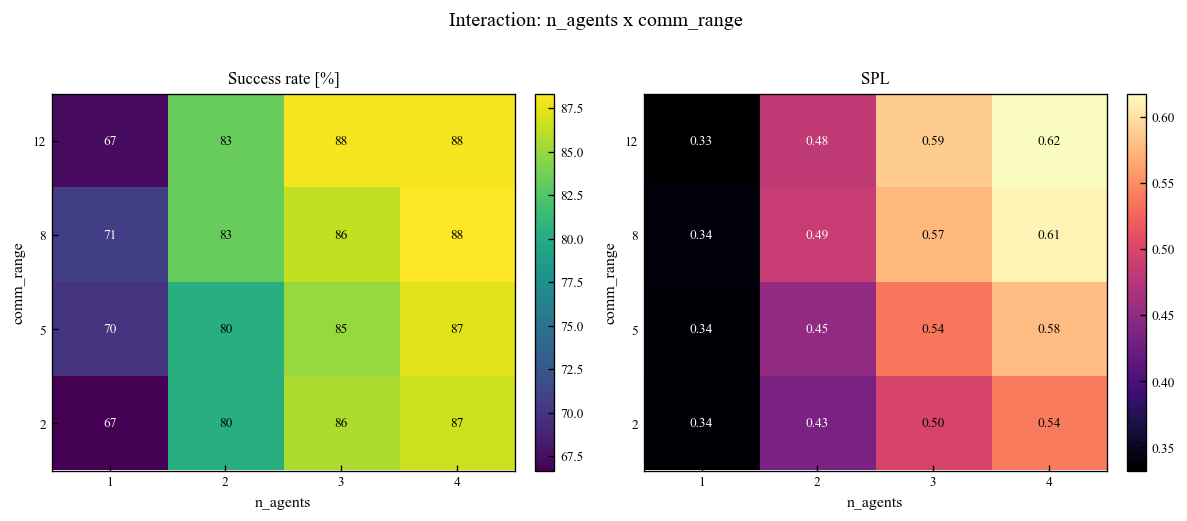

  saved testing_results/plots/fig_heatmap_nagents_comm.png


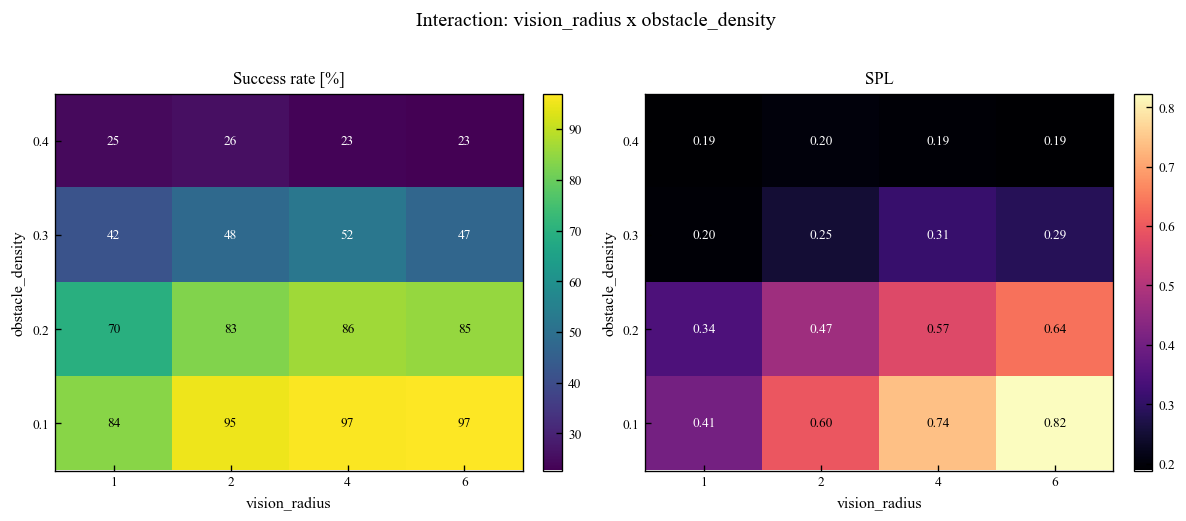

  saved testing_results/plots/fig_heatmap_vision_density.png


In [6]:
def plot_heatmap(name):
    p = os.path.join(CSV_DIR, f"heatmap_{name}.csv")
    if not os.path.exists(p):
        print("  (skip) no", p); return
    df = pd.read_csv(p)
    xname, yname = df.x_name.iloc[0], df.y_name.iloc[0]
    xs = sorted(df.x.unique()); ys = sorted(df.y.unique())

    def grid(col):
        g = np.full((len(ys), len(xs)), np.nan)
        for _, r in df.iterrows():
            g[ys.index(r.y), xs.index(r.x)] = r[col]
        return g

    fig, axs = plt.subplots(1, 2, figsize=(10.0, 4.2))
    for ax, (col, ttl, fmt, scale, cmap) in zip(
        axs, [("success_rate", "Success rate [%]", "{:.0f}", 100, "viridis"),
              ("spl",          "SPL",              "{:.2f}", 1,   "magma")]):
        g  = grid(col) * scale
        im = ax.imshow(g, origin="lower", aspect="auto", cmap=cmap)
        ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs)
        ax.set_yticks(range(len(ys))); ax.set_yticklabels(ys)
        ax.set_xlabel(xname); ax.set_ylabel(yname); ax.set_title(ttl)
        ax.grid(False)
        vmid = np.nanmin(g) + 0.55*(np.nanmax(g)-np.nanmin(g))
        for iy in range(len(ys)):
            for ix in range(len(xs)):
                v = g[iy, ix]
                if not np.isnan(v):
                    ax.text(ix, iy, fmt.format(v), ha="center", va="center",
                            fontsize=8, color="white" if v < vmid else "black")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Interaction: {xname} x {yname}", fontsize=12, y=1.02)
    fig.tight_layout()
    out = os.path.join(PLOT_DIR, f"fig_heatmap_{name}.png")
    fig.savefig(out); plt.show(); print("  saved", rel(out))

for nm in ["nagents_comm", "vision_density"]:
    plot_heatmap(nm)

## 4b — Summary table

In-distribution vs OOD aggregates per axis — the generalization-gap headline.

In [7]:
rows = []
for axis in ["n_agents", "vision", "comm", "density", "max_steps"]:
    df = load_agg(axis)
    if df is None:
        continue
    for label, sub in [("in-dist", df[df.in_dist == 1]), ("OOD", df[df.in_dist == 0])]:
        if sub.empty:
            continue
        rows.append({
            "axis": axis, "region": label,
            "success_%":  round(100*sub.success_rate.mean(), 1),
            "reward":     round(sub.mean_reward.mean(), 1),
            "coverage_%": round(100*sub.coverage.mean(), 1),
            "SPL":        round(sub.spl.mean(), 3),
        })
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(CSV_DIR, "summary_table.csv"), index=False)
summary

,axis,region,success_%,reward,coverage_%,SPL
0,n_agents,in-dist,82.7,74.1,52.6,0.475
1,n_agents,OOD,90.0,-18.5,55.0,0.625
2,vision,in-dist,84.5,57.1,55.3,0.526
3,vision,OOD,86.3,70.0,68.3,0.627
4,comm,in-dist,88.0,74.0,53.6,0.552
5,comm,OOD,88.4,74.9,53.9,0.554
6,density,in-dist,81.4,13.9,52.8,0.525
7,density,OOD,52.6,-280.3,37.3,0.406
8,max_steps,in-dist,87.6,71.2,53.7,0.541
9,max_steps,OOD,74.9,65.5,50.4,0.489


## 5 — Mirror the figures into `report/figures/`

Copies everything this notebook generated into the directory `report/main.tex`
reads from. Figures produced elsewhere (`fig_training_curves`, `fig_schedules`,
`fig_training_eval`) are left untouched.

In [8]:
GENERATED = ([f"fig_{a}.png" for a in
              ["n_agents", "vision", "comm", "density", "max_steps"]]
             + ["fig_epoch.png", "fig_fault.png", "fig_nbroken.png",
                "fig_heatmap_nagents_comm.png", "fig_heatmap_vision_density.png"])

os.makedirs(FIG_DIR, exist_ok=True)
for name in GENERATED:
    src = os.path.join(PLOT_DIR, name)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(FIG_DIR, name))
        print("  mirrored", name)
    else:
        print("  (missing)", name)

  mirrored fig_n_agents.png
  mirrored fig_vision.png
  mirrored fig_comm.png
  mirrored fig_density.png
  mirrored fig_max_steps.png
  mirrored fig_epoch.png
  mirrored fig_fault.png
  mirrored fig_nbroken.png
  mirrored fig_heatmap_nagents_comm.png
  mirrored fig_heatmap_vision_density.png
